In [1]:
!pip install -q langchain_google_genai langgraph fastmcp langchain_mcp_adapters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.5/367.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.3/184.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.9/469.9 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.2/69.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.6/222.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.6/20

In [89]:
import os
import getpass
import math
import threading
import json
import re

#Langchain mensajes
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage

#Message state
from langgraph.graph.message import MessagesState
from typing import TypedDict

#Langchain chat model (Google)
from langchain_google_genai import ChatGoogleGenerativeAI

#Herramientas
from langchain_core.tools import tool
from langchain_core.runnables.base import RunnableBinding

#MCP
from fastmcp import FastMCP
from langchain_mcp_adapters.client import MultiServerMCPClient

#Workflow
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#Memoria
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.memory import InMemorySaver

from IPython.display import Image, display

In [3]:
# Ingresa el API key
os.environ["GOOGLE_API_KEY"]: str = getpass.getpass("Ingresa tu Google AI API key: ")

Ingresa tu Google AI API key: ··········


#### Llamado de herramientas

En **Langchain** se utiliza el decorador **@tool** para crear herramientas.

> Para utilizar esta funcionalidad se debe utilizar un modelo que soporte el llamado a herramientas.


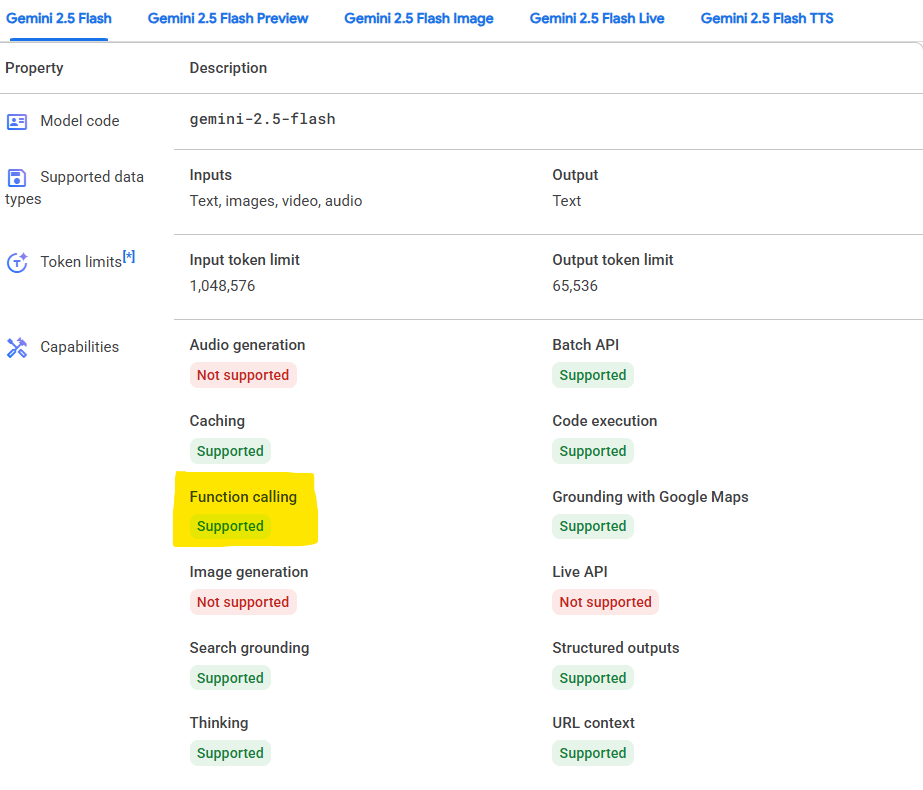


> Esto permitirá que el modelo pueda disponer de las herramientas cuando sea pertinente e invocarlas con los argumentos adecuados.

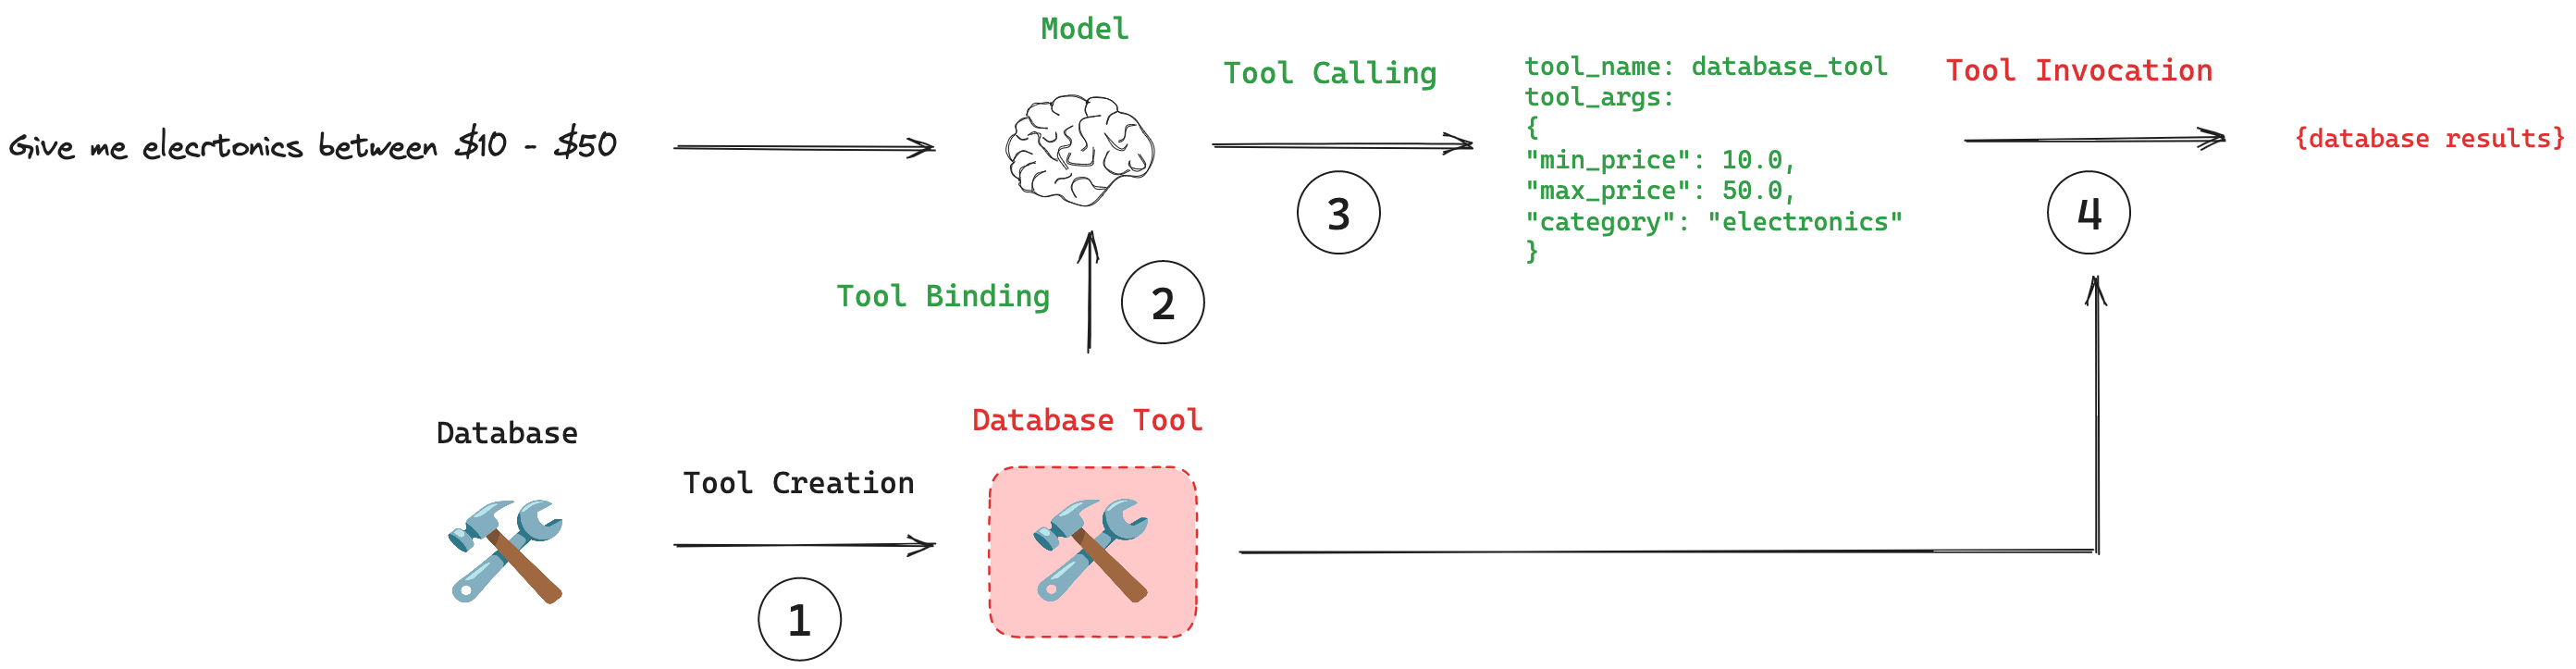

##### Definición de herramientas

In [9]:
@tool
def suma_primeros_n_enteros(n: int) -> int:
  """
  Calcula la suma de los primeros n enteros positivos.

  Args:
    n: Un número entero positivo.

  Returns:
    La suma de los primeros n enteros positivos.
  """
  if n < 1:
      raise ValueError("n debe ser un número entero positivo.")
  return n * (n + 1) // 2

@tool
def calcula_factorial(n: int) -> int:
  """
  Calcula el factorial de un número entero positivo.

  Args:
    n: Un número entero positivo.

  Returns:
    El factorial de n.
  """
  if n < 0:
        raise ValueError("n debe ser un número entero no negativo.")

  return math.factorial(n)

@tool
def calcular_promedio(valores: list[float]) -> list:
  """
  Calcula el promedio de una lista de valores.

  Args:
    valores: Una lista de valores numéricos.

  Returns:
    Una lista con el promedio de los valores.
  """
  if not valores:
        raise ValueError("La lista de valores no puede estar vacía.")
  return sum(valores) / len(valores)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
#Inicializamos nuestro modelo chat
model: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

#Anexamos las herramientas al modelo
tools: list = [suma_primeros_n_enteros, calcula_factorial, calcular_promedio]
modelo: RunnableBinding = model.bind_tools( tools )

##### Definición del grafo: Router

In [11]:
#Definición del estado del grafo
class Estado(MessagesState):
    ...

In [12]:
mensaje_sistema: SystemMessage = SystemMessage('Eres un asistente, resuelve las dudas del usuario.')

def asistente(state: MessagesState) -> MessagesState:
  """
  Genera una respuesta del modelo usando el estado actual.

  Args:
      state (MessagesState): Mensajes previos del flujo.

  Returns:
      MessagesState: Nuevo estado con la respuesta generada.
  """
  prompt: SystemMessage = mensaje_sistema
  response: AIMessage = modelo.invoke([prompt] + state["messages"])
  return {"messages": [response]}

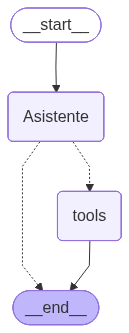

In [17]:
workflow: StateGraph = StateGraph(Estado)
workflow.set_entry_point("Asistente")

#Nodo asistente
workflow.add_node("Asistente", asistente)

#Nodo Herramienta
tool_node: ToolNode = ToolNode(tools=tools) #Se define un nodo especial para el llamado de las herramientas
workflow.add_node("tools", tool_node)

#Condición: tool_condition permite identificar si se realizó una llamada a una herramienta
workflow.add_conditional_edges(
    "Asistente",
    tools_condition,
)

workflow.add_edge("tools", END)

workflow_compilado: CompiledStateGraph = workflow.compile()

display(Image(workflow_compilado.get_graph().draw_mermaid_png()))

In [18]:
#Evaluamos las respuestas
messages: list[HumanMessage] = [HumanMessage(content="La suma de los primeros 10 números enteros.")]

messages: list[HumanMessage, AIMessage, ToolMessage] = workflow_compilado.invoke({"messages": messages})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

La suma de los primeros 10 números enteros.
================================== Ai Message ==================================
Tool Calls:
  suma_primeros_n_enteros (d5972505-3e84-42d5-826c-b72eb2ba854b)
 Call ID: d5972505-3e84-42d5-826c-b72eb2ba854b
  Args:
    n: 10
================================= Tool Message =================================
Name: suma_primeros_n_enteros

55


In [19]:
#Evaluamos si podemos reutilizar resultados anteriores
messages: list[HumanMessage] = [HumanMessage(content="Al resultado anterior, súmale 5")]

messages: list[HumanMessage, AIMessage, ToolMessage] = workflow_compilado.invoke({"messages": messages})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Al resultado anterior, súmale 5
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Lo siento, para poder ayudarte necesito saber a qué resultado te refieres o cuál es el número al que le quieres sumar 5.', 'extras': {'signature': 'Cq4OAdHtim/bd0he2V1BsXfiHcwQgFgqLKdkJos0z2hqDGIa4VDPtA5mojS6I/24NVolPoTSTQ1pQ2vwirNhwZjfBY6lCXaKpxe/UzjFw726ySzefENd2l8Ey1R3X1/fRVl2tLuTPYBAuM281ZvlQxdtPbneiO/UUFG5Br+r3hx3oxucMrBs4PoVLaviz9FahPLsm6zv7tnB4z5fa8GPoRQ5QnPB19tUm6f1Dx/lZ3XAipG32Pz1bTKV7R6Yn09VbWKz1G962LlSgU0XaJS7dJ7wATpLx/mAQZtJ6ANYffpxzsPrsBY/j+kEDTYDDjM9r/5mZ9yzpH1mnii7xH+iUyf5+VSxm4ML3NxWbAE6vC47vkcd/OI//26osBYGARcIAjOPgOoZjBQWEynw886K7O40oYtqEIB6p4EhKC19Xt9zaUWXrvvWeoQT1xfTtKvI+wk8sM/3S2V5lH+ke/rzyWbYGYPklbxLvlvToZjLpnALWpPZ/p738uV/VKk2lj09PLa37QsgTSEQFPazKrR0XN7iRS4RdEAqeT5bPnZjfYfEih0D16kFSAzPBOYWBZQDZvbQBsgPqLfS/a2PnCHsbWANgcgANyvezU+2zC4zsikWF4tPiZx0b

#### Memoria

La memoria a corto plazo mantiene el historial de mensajes dentro de una sesión. LangGraph gestiona esta memoria como parte del estado del agente. El estado se guarda en una base de datos mediante un checkpointer, lo que permite reanudar el hilo en cualquier momento.

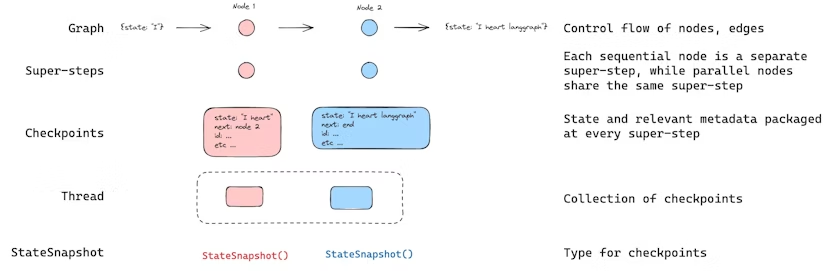

**Fuente:** https://docs.langchain.com/oss/python/concepts/memory#memory-overview

In [23]:
#Inicializamos la memoria
memory: InMemorySaver = MemorySaver()
workflow_compilado_memoria: CompiledStateGraph = workflow.compile(checkpointer=memory)

In [26]:
#Inicializamos la configuración, se debe especificar el hilo de la conversación
config: dict = {"configurable": {"thread_id": "1"}}

messages: list[HumanMessage] = [HumanMessage(content="La suma de los primeros 10 números enteros.")]

messages: list[HumanMessage, AIMessage, ToolMessage] = workflow_compilado_memoria.invoke({"messages": messages}, config)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

La suma de los primeros 10 números enteros.
================================== Ai Message ==================================
Tool Calls:
  suma_primeros_n_enteros (88eebb99-c10a-4918-98f8-1cd481431ae1)
 Call ID: 88eebb99-c10a-4918-98f8-1cd481431ae1
  Args:
    n: 10
================================= Tool Message =================================
Name: suma_primeros_n_enteros

55


In [27]:
#Evaluamos si podemos reutilizar resultados anteriores
config: dict = {"configurable": {"thread_id": "1"}}

messages: list[HumanMessage] = [HumanMessage(content="Al resultado anterior, súmale 5")]

messages: list[HumanMessage, AIMessage, ToolMessage] = workflow_compilado_memoria.invoke({"messages": messages}, config)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

La suma de los primeros 10 números enteros.
================================== Ai Message ==================================
Tool Calls:
  suma_primeros_n_enteros (88eebb99-c10a-4918-98f8-1cd481431ae1)
 Call ID: 88eebb99-c10a-4918-98f8-1cd481431ae1
  Args:
    n: 10
================================= Tool Message =================================
Name: suma_primeros_n_enteros

55
================================ Human Message =================================

Al resultado anterior, súmale 5
================================== Ai Message ==================================

El resultado anterior fue 55. Si le sumamos 5, obtenemos 60.


#### Definición del grafo: React

In [62]:
mensaje_sistema: SystemMessage = SystemMessage(
    'Eres un agente experto en cálculos matemáticos básicos.'
    'Tu objetivo es ayudar al usuario a resolver problemas numéricos paso a paso utilizando las herramientas disponibles.'
    'Debes razonar antes de usar una herramienta y explicar brevemente tu razonamiento.')

def asistente(state: MessagesState) -> MessagesState:
  """
  Genera una respuesta del modelo usando el estado actual.

  Args:
      state (MessagesState): Mensajes previos del flujo.

  Returns:
      MessagesState: Nuevo estado con la respuesta generada.
  """
  prompt: SystemMessage = mensaje_sistema
  response: AIMessage = modelo.invoke([prompt] + state["messages"])
  return {"messages": [response]}

In [63]:
workflow: StateGraph = StateGraph(Estado)
workflow.set_entry_point("Asistente")

#Nodo asistente
workflow.add_node("Asistente", asistente)

#Nodo Herramienta
tool_node: ToolNode = ToolNode(tools=tools) #Se define un nodo especial para el llamado de las herramientas
workflow.add_node("tools", tool_node)

#Condición: tool_condition permite identificar si se realizó una llamada a una herramienta
workflow.add_conditional_edges(
    "Asistente",
    tools_condition,
)

workflow.add_edge("tools", "Asistente")

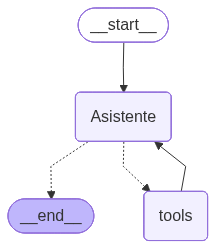

In [64]:
#Inicializamos la memoria
memory: InMemorySaver = MemorySaver()
workflow_compilado_memoria: CompiledStateGraph = workflow.compile(checkpointer=memory)

display(Image(workflow_compilado_memoria.get_graph().draw_mermaid_png()))

In [65]:
#Inicializamos la configuración, se debe especificar el hilo de la conversación
config: dict = {"configurable": {"thread_id": "1"}}

messages: list[HumanMessage] = [HumanMessage(content="Calcula el promedio de los 10 primeros números enteros. Al resultado, súmale el factorial de 5.")]

messages: list[HumanMessage, AIMessage, ToolMessage] = workflow_compilado_memoria.invoke({"messages": messages}, config)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Calcula el promedio de los 10 primeros números enteros. Al resultado, súmale el factorial de 5.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Para calcular el promedio de los 10 primeros números enteros, necesito la lista de esos números. Los primeros 10 números enteros son: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10.\n\nLuego, usaré la herramienta `calcular_promedio` para obtener el promedio de esta lista.\n\nDespués, calcularé el factorial de 5 usando la herramienta `calcula_factorial`.\n\nFinalmente, sumaré ambos resultados.', 'extras': {'signature': 'CuIEAdHtim+7b7bwBMwzbZAGajYjKfvFC2UMsRkIv0WAfge7d+XoxaMZ+CnhSArmURmMv3SAixDiz5fLz7LSD/9TgiXEQmZqvreuIaYHXttE9caIMVU8fXpiZA/3pTXjpjtzPpKEJUtQu0dzyJ9h3m7d4TYiuX3BfMbW15Agps08OrpvZ6moV4nlTACsWM1lc2j8Uo/JMfmIZssLAzVkvoyDKZ6c12y/OoWxbTxIaudH1JNLyKmftIkDvhqprvrNF9zpUNKLHneAOna7MgG7EbQ5i9oO8ecOZrhrizKANHzhm9nR0CR

In [66]:
messages = [HumanMessage(content="Hola")]
messages = workflow_compilado_memoria.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Calcula el promedio de los 10 primeros números enteros. Al resultado, súmale el factorial de 5.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Para calcular el promedio de los 10 primeros números enteros, necesito la lista de esos números. Los primeros 10 números enteros son: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10.\n\nLuego, usaré la herramienta `calcular_promedio` para obtener el promedio de esta lista.\n\nDespués, calcularé el factorial de 5 usando la herramienta `calcula_factorial`.\n\nFinalmente, sumaré ambos resultados.', 'extras': {'signature': 'CuIEAdHtim+7b7bwBMwzbZAGajYjKfvFC2UMsRkIv0WAfge7d+XoxaMZ+CnhSArmURmMv3SAixDiz5fLz7LSD/9TgiXEQmZqvreuIaYHXttE9caIMVU8fXpiZA/3pTXjpjtzPpKEJUtQu0dzyJ9h3m7d4TYiuX3BfMbW15Agps08OrpvZ6moV4nlTACsWM1lc2j8Uo/JMfmIZssLAzVkvoyDKZ6c12y/OoWxbTxIaudH1JNLyKmftIkDvhqprvrNF9zpUNKLHneAOna7MgG7EbQ5i9oO8ecOZrhrizKANHzhm9nR0CR

#### MCP (Model Context Protocol)

*   MCP (Model Context Protocol) es un estándar de código abierto para conectar aplicaciones de IA con sistemas externos.
*   Con MCP, aplicaciones como Claude o ChatGPT pueden conectarse a fuentes de datos (por ejemplo, archivos locales o bases de datos), herramientas (como buscadores o calculadoras) y flujos de trabajo (como prompts especializados), permitiéndoles acceder a información clave y ejecutar tareas.

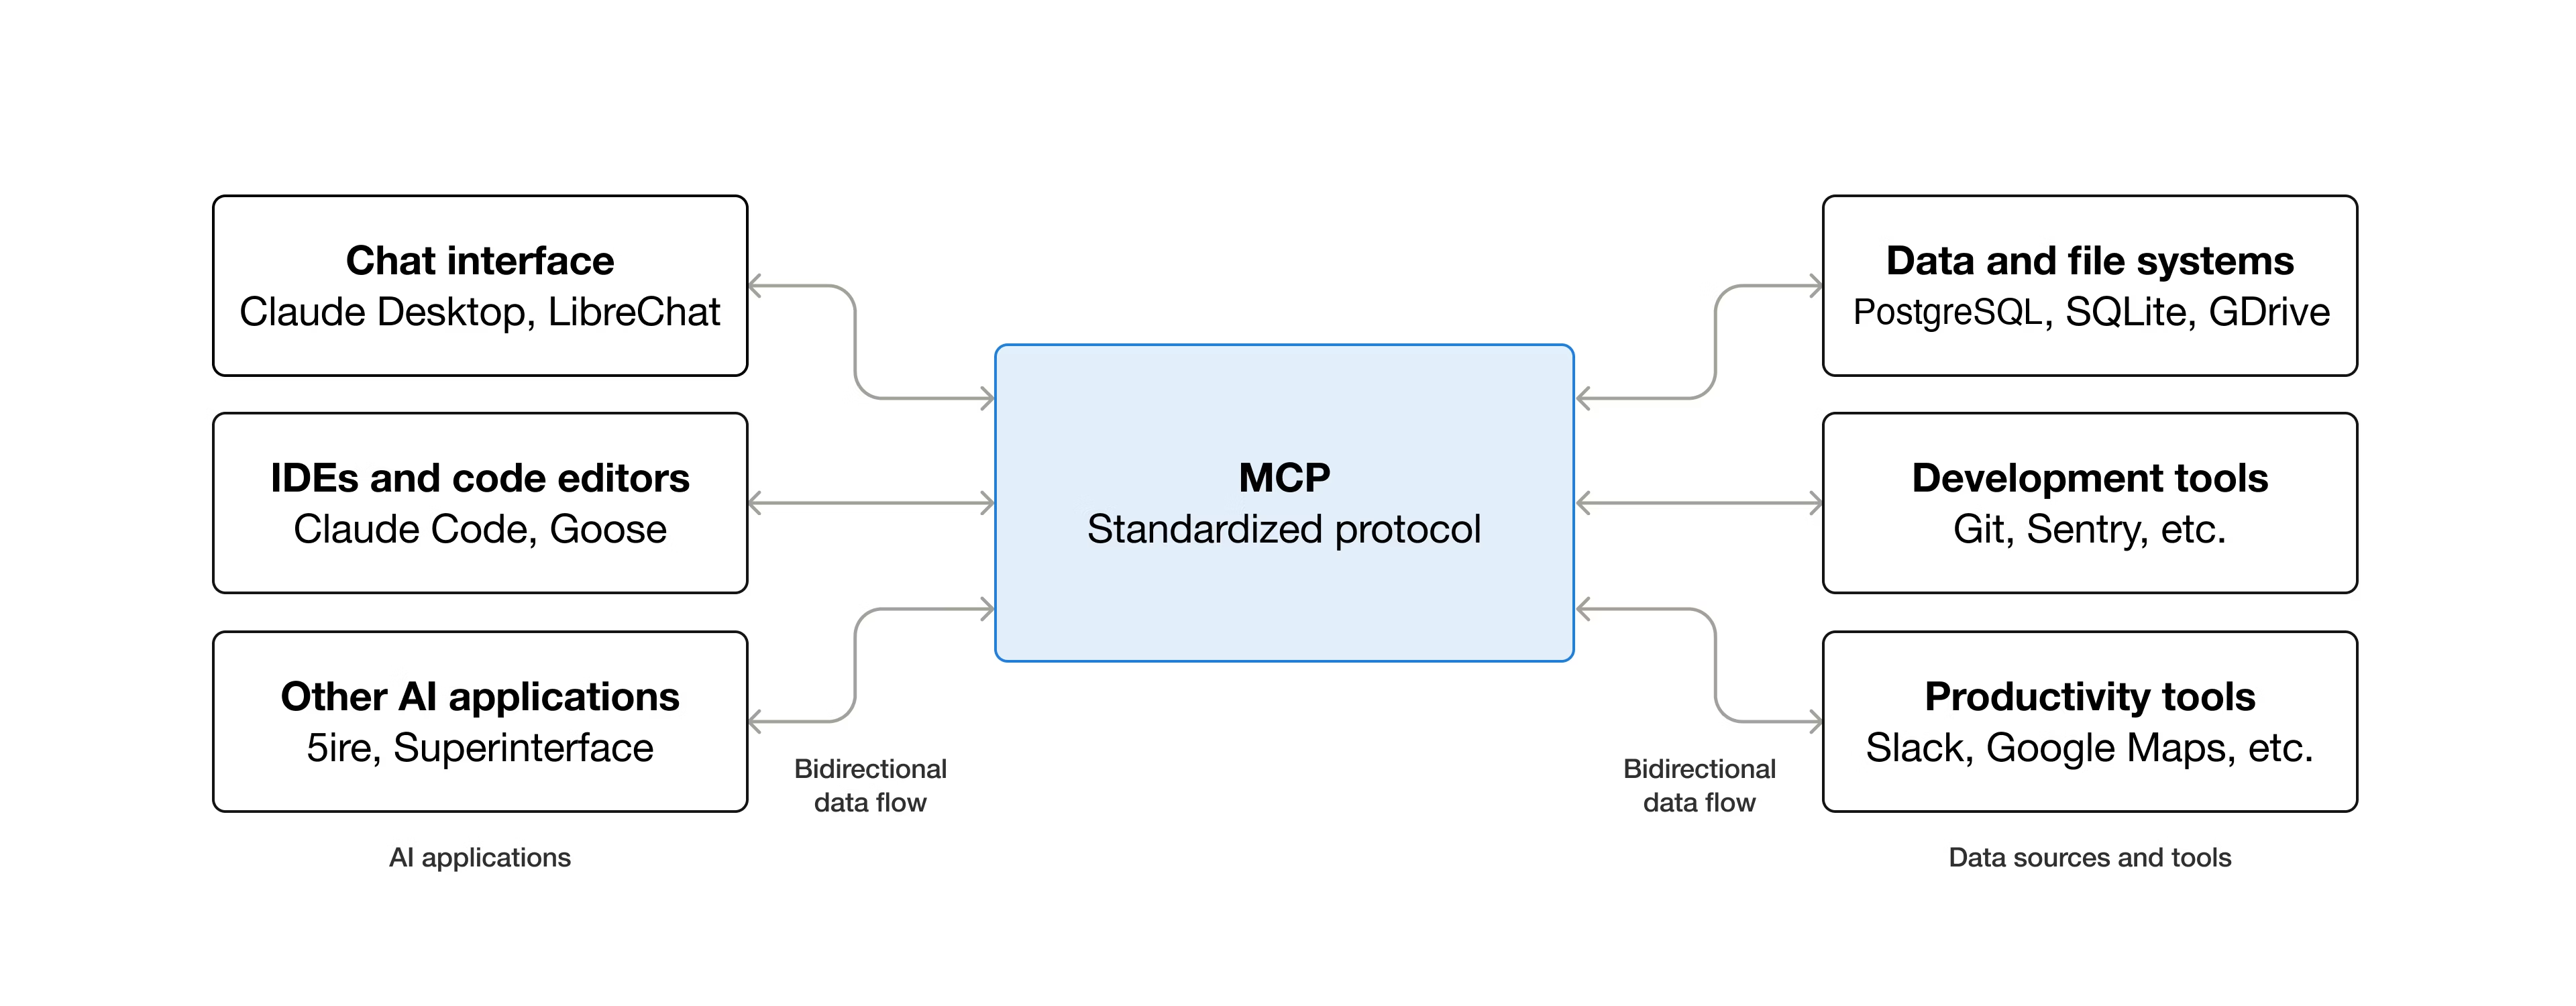

**Fuente:** https://modelcontextprotocol.io/docs/getting-started/intro

##### Definición de herramientas

In [44]:
mcp: FastMCP = FastMCP(name="mcp-tools")

@mcp.tool()
def costo_unitario(costo_materia_prima: float, costo_mano_obra: float, cantidad: int) -> float:
  """
    Calcula el costo unitario de producción.

    Args:
        costo_materia_prima (float): Costo total de materia prima.
        costo_mano_obra (float): Costo total de mano de obra.
        cantidad (int): Unidades producidas.

    Returns:
        float: Costo por unidad.
    """
  costo: float = (costo_materia_prima + costo_mano_obra ) / cantidad
  return costo

@mcp.tool()
def costo_venta_unitario(costo_unitario: float, margen_bruto: float = 0.05) -> float:
  """
    Calcula el costo de venta unitario aplicando un margen bruto.

    Args:
        costo_unitario (float): Costo base por unidad.
        margen_bruto (float, opcional): Porcentaje de margen. Por defecto 0.05.

    Returns:
        float: Costo de venta por unidad.
    """
  costo: float = costo_unitario * (1 + margen_bruto)
  return costo

def run_server() -> None:
  """
  Ejecuta el servidor FastMCP en modo HTTP.

  Arranca el servidor en localhost:8000 para exponer las herramientas
  definidas mediante MCP.
  """
  mcp.run(transport="http", host="localhost", port=8000)

thread = threading.Thread(target=run_server, daemon=True)
thread.start()

print("✅ fastmcp server corriendo")

✅ fastmcp server corriendo


╭──────────────────────────────────────────────────────────────────────────────╮                  
                 │                                                                              │                  
                 │                         ▄▀▀ ▄▀█ █▀▀ ▀█▀ █▀▄▀█ █▀▀ █▀█                        │                  
                 │                         █▀  █▀█ ▄▄█  █  █ ▀ █ █▄▄ █▀▀                        │                  
                 │                                                                              │                  
                 │                               FastMCP 2.13.0.2                               │                  
                 │                                                                              │                  
                 │                                                                              │                  
                 │                  🖥  Server name: mcp-tools                                   │                  
                 │                                                                              │                  
                 │                  📦 Transport:   HTTP                                        │                  
                 │                  🔗 Server URL:  http://localhost:8000/mcp                   │                  
                 │                                                                              │                  
                 │                  📚 Docs:        https://gofastmcp.com                       │                  
                 │                  🚀 Hosting:     https://fastmcp.cloud                       │                  
                 │                                                                              │                  
                 ╰──────────────────────────────────────────────────────────────────────────────╯

In [69]:
mcp_tools: MultiServerMCPClient = MultiServerMCPClient({
        "mcp-tools": {
            "transport": "streamable_http",
            "url": "http://localhost:8000/mcp",
        }
        })

tools: list = await mcp_tools.get_tools()

INFO:     ::1:60492 - "POST /mcp HTTP/1.1" 200 OK
INFO:     ::1:60504 - "POST /mcp HTTP/1.1" 202 Accepted
INFO:     ::1:60510 - "GET /mcp HTTP/1.1" 200 OK
INFO:     ::1:60518 - "POST /mcp HTTP/1.1" 200 OK
INFO:     ::1:60534 - "DELETE /mcp HTTP/1.1" 200 OK


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [70]:
#Inicializamos nuestro modelo chat
model_mcp: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

#Anexamos las herramientas al modelo
model_mcp: RunnableBinding = model_mcp.bind_tools( tools )

In [75]:
mensaje_sistema: SystemMessage = SystemMessage(
    'Eres un asistente, resuelve las dudas del usuario.')

async def asistente(state: MessagesState) -> MessagesState:
  """
  Genera una respuesta del modelo usando el estado actual.

  Args:
      state (MessagesState): Mensajes previos del flujo.

  Returns:
      MessagesState: Nuevo estado con la respuesta generada.
  """
  prompt: SystemMessage  = mensaje_sistema
  response: AIMessage = await model_mcp.ainvoke([prompt] + state["messages"])
  return {"messages": [response]}

In [76]:
workflow: StateGraph = StateGraph(Estado)
workflow.set_entry_point("Asistente")

#Nodo asistente
workflow.add_node("Asistente", asistente)

#Nodo Herramienta
tool_node: ToolNode = ToolNode(tools=tools) #Se define un nodo especial para el llamado de las herramientas
workflow.add_node("tools", tool_node)

#Condición: tool_condition permite identificar si se realizó una llamada a una herramienta
workflow.add_conditional_edges(
    "Asistente",
    tools_condition,
)

workflow.add_edge("tools", "Asistente")

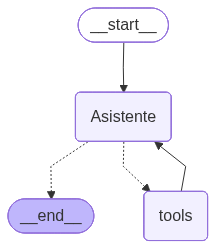

In [85]:
#Inicializamos la memoria
memory: InMemorySaver = MemorySaver()
workflow_compilado_memoria: CompiledStateGraph = workflow.compile(checkpointer=memory)

display(Image(workflow_compilado_memoria.get_graph().draw_mermaid_png()))

In [86]:
#Inicializamos la configuración, se debe especificar el hilo de la conversación
config: dict = {"configurable": {"thread_id": "1"}}

messages: list[HumanMessage] = [HumanMessage(content="si el costo total de la materia prima es $4,000, el de mano de obra $1,500 y fabrico cantidad 400 unidades, cuál es el precio unitario? Además, calcula el precio de venta")]

messages: list[HumanMessage, AIMessage, ToolMessage] = await workflow_compilado_memoria.ainvoke({"messages": messages}, config)

for m in messages['messages']:
    m.pretty_print()

INFO:     ::1:48324 - "POST /mcp HTTP/1.1" 200 OK
INFO:     ::1:48336 - "POST /mcp HTTP/1.1" 202 Accepted
INFO:     ::1:48340 - "GET /mcp HTTP/1.1" 200 OK
INFO:     ::1:48346 - "POST /mcp HTTP/1.1" 200 OK
INFO:     ::1:48356 - "POST /mcp HTTP/1.1" 200 OK
INFO:     ::1:56716 - "DELETE /mcp HTTP/1.1" 200 OK


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


INFO:     ::1:56726 - "POST /mcp HTTP/1.1" 200 OK
INFO:     ::1:56742 - "POST /mcp HTTP/1.1" 202 Accepted
INFO:     ::1:56746 - "GET /mcp HTTP/1.1" 200 OK
INFO:     ::1:56754 - "POST /mcp HTTP/1.1" 200 OK
INFO:     ::1:56758 - "POST /mcp HTTP/1.1" 200 OK
INFO:     ::1:56760 - "DELETE /mcp HTTP/1.1" 200 OK


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


================================ Human Message =================================

si el costo total de la materia prima es $4,000, el de mano de obra $1,500 y fabrico cantidad 400 unidades, cuál es el precio unitario? Además, calcula el precio de venta
================================== Ai Message ==================================
Tool Calls:
  costo_unitario (9110a951-e19c-42ea-b809-4f7f9504d82c)
 Call ID: 9110a951-e19c-42ea-b809-4f7f9504d82c
  Args:
    costo_materia_prima: 4000
    cantidad: 400
    costo_mano_obra: 1500
================================= Tool Message =================================
Name: costo_unitario

13.75
================================== Ai Message ==================================
Tool Calls:
  costo_venta_unitario (a88b51b8-c1ed-4fa1-a634-590927d57f42)
 Call ID: a88b51b8-c1ed-4fa1-a634-590927d57f42
  Args:
    costo_unitario: 13.75
================================= Tool Message =================================
Name: costo_venta_unitario

14.4375
=======

In [87]:
messages: list[HumanMessage] = [HumanMessage(content="Ok, ahora calcula el precio de venta con un margen del 10%")]

messages: list[HumanMessage, AIMessage, ToolMessage] = await workflow_compilado_memoria.ainvoke({"messages": messages}, config)

for m in messages['messages']:
    m.pretty_print()

INFO:     ::1:51902 - "POST /mcp HTTP/1.1" 200 OK
INFO:     ::1:51904 - "GET /mcp HTTP/1.1" 200 OK
INFO:     ::1:51910 - "POST /mcp HTTP/1.1" 202 Accepted
INFO:     ::1:51912 - "POST /mcp HTTP/1.1" 200 OK
INFO:     ::1:51914 - "POST /mcp HTTP/1.1" 200 OK
INFO:     ::1:51924 - "DELETE /mcp HTTP/1.1" 200 OK


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


================================ Human Message =================================

si el costo total de la materia prima es $4,000, el de mano de obra $1,500 y fabrico cantidad 400 unidades, cuál es el precio unitario? Además, calcula el precio de venta
================================== Ai Message ==================================
Tool Calls:
  costo_unitario (9110a951-e19c-42ea-b809-4f7f9504d82c)
 Call ID: 9110a951-e19c-42ea-b809-4f7f9504d82c
  Args:
    costo_materia_prima: 4000
    cantidad: 400
    costo_mano_obra: 1500
================================= Tool Message =================================
Name: costo_unitario

13.75
================================== Ai Message ==================================
Tool Calls:
  costo_venta_unitario (a88b51b8-c1ed-4fa1-a634-590927d57f42)
 Call ID: a88b51b8-c1ed-4fa1-a634-590927d57f42
  Args:
    costo_unitario: 13.75
================================= Tool Message =================================
Name: costo_venta_unitario

14.4375
=======

#### Definición del grafo: Reflexión

Mejorar una función de python

In [153]:
#Definimos el estado del grafo

class Estado(TypedDict):
    funcion: str
    historia: list[str]
    revision: list[str]
    satisfecho: bool

In [154]:
#Inicializamos nuestro modelo chat
modelo: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

In [158]:
def mejora_funcion(state: Estado):

    #En caso no existan revisiones devolver un string vacío
    revision: str=  "" if len(state['revision']) ==0 else state['revision']

    #Instrucciones para la escritura de la función
    prompt: HumanMessage = HumanMessage(
        content=f"""
      Mejorarás la siguiente función de Python. Soluciona los errores y escríbela de forma clara. Si recibes revisiones utilízalas para mejorar la función.

      Función:
      {state['funcion']}

      Revisión:
      {revision}

      Función mejorada:

      Retorna solo el código de la función mejorada.
      """)

    respuesta: AIMessage = modelo.invoke([prompt])
    nuevo_codigo: str = respuesta.content.strip()
    return {
        "funcion": nuevo_codigo,
        "historia": state["historia"] + [respuesta]
        }


def revisor(state: Estado):
    prompt: HumanMessage = HumanMessage(
        content=f"""
              Eres un revisor senior de Python. Evalúa la siguiente función en cuanto a corrección, claridad, manejo de errores y buenas prácticas.

              === FUNCIÓN A EVALUAR ===
              {state['funcion']}

              === TAREA ===
              Determina:
              1. Si la función necesita más mejoras.
              2. Una breve explicación de lo que falta o lo que está bien hecho.

              === CRITERIOS DE ACEPTACIÓN ===
              Una función es aceptable solo si TODOS son verdaderos:
              - Implementación correcta y lógica
              - Maneja casos edge y entradas inválidas de forma segura
              - Código claro y legible
              - Incluye docstring y type hints
              - Usa un enfoque eficiente cuando aplica
              - Sigue buenas prácticas de Python / PEP8

              === FORMATO DE SALIDA (IMPORTANTE) ===
              Devuelve SOLO JSON con la siguiente estructura:

              {{
                'continuar': 'SATISFECHO' o 'MEJORAR',
                'revision': '<explicación muy corta>'
              }}

              Ejemplos:
              {{
                'continuar': 'MEJORAR',
                'revision': 'Faltan type hints y no maneja casos edge.'
              }}

              {{
                'continuar': 'SATISFECHO',
                'revision': 'La función es limpia, correcta y robusta.'
              }}
            """)

    respuesta: AIMessage = modelo.invoke([prompt])

    #Limpieza de la repuesta en formato json
    text: str = respuesta.content.replace("```json", "").replace("```", "").strip()

    try:
        resultado: dict = json.loads(text)

    except json.JSONDecodeError:
        match: re.Match = re.search(r"\{.*\}", text, re.DOTALL)

        if match:
            try:
                resultado: dict = json.loads(match.group())
            except:

                resultado: dict = {"continuar": 'SATISFECHO', "revision": "Invalid JSON response."}
        else:
            resultado: dict = {"continuar": 'SATISFECHO', "revision": "No JSON found in response."}

    status: bool = 'SATISFECHO' in resultado['continuar']

    return {"satisfecho": status, "revision": state['revision'] + [resultado['revision']], "historia": state["historia"] + [respuesta]}

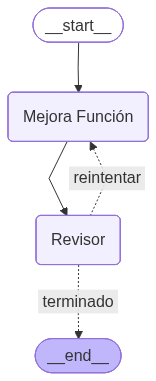

In [161]:
workflow: StateGraph = StateGraph(Estado)
workflow.set_entry_point("Mejora Función")

#Nodos
workflow.add_node("Mejora Función", mejora_funcion)
workflow.add_node("Revisor", revisor)

workflow.add_edge("Mejora Función", "Revisor")

#Condición: Si el revisor está satisfecho o existen más de 5 revisiones
workflow.add_conditional_edges(
    "Revisor",
    lambda state: "terminado" if state["satisfecho"] or len(state["revision"]) > 5 else "reintentar",
    {
        "terminado": END,
        "reintentar": "Mejora Función"
    }
)

workflow_compilado: CompiledStateGraph = workflow.compile()

display(Image(workflow_compilado.get_graph().draw_mermaid_png()))

In [162]:
#Probamos el grafo
funcion_inicial = """
def factorial(n):
    if n == 0:
        return 1
    return n * factorial(n-1)
"""

result: dict = workflow_compilado.invoke({
    "funcion": funcion_inicial,
    "historia": [],
    "revision": [],
    "satisfecho": False
})

for m in result['historia']:
    m.pretty_print()

================================== Ai Message ==================================

```python
def factorial(n: int) -> int:
    """
    Calcula el factorial de un número entero no negativo de forma recursiva.

    El factorial de un entero no negativo n, denotado como n!, es el producto
    de todos los enteros positivos menores o iguales a n.
    El factorial de 0 es 1.

    Args:
        n: Un número entero no negativo.

    Returns:
        El valor del factorial de n.

    Raises:
        TypeError: Si n no es un número entero.
        ValueError: Si n es un número negativo.
    """
    # Validación de entrada: Asegura que n sea un entero.
    if not isinstance(n, int):
        raise TypeError("El argumento 'n' debe ser un número entero.")

    # Validación de entrada: Asegura que n no sea negativo.
    if n < 0:
        raise ValueError("El argumento 'n' debe ser un número no negativo.")

    # Caso base: El factorial de 0 es 1.
    if n == 0:
        return 1
    # Caso recursivo: 